# Cats at The Met EDA

Exploring cats in art at The Met through The Met Open Access dataset.

In [170]:
import pandas as pd
import re
import numpy as np
import requests
import os
from collections import defaultdict, Counter
from itertools import chain
import matplotlib.pyplot as plt
import seaborn as sns

In [216]:
pd.options.display.max_columns = None
pd.options.display.max_colwidth = None

## Download Data

Download The Metropolitan Museum of Art Open Access CSV from [Github](https://github.com/metmuseum/openaccess)

In [171]:
# url for raw data from https://github.com/metmuseum/openaccess/blob/master/MetObjects.csv
OPEN_ACCESS_CSV_URL = "https://media.githubusercontent.com/media/metmuseum/openaccess/refs/heads/master/MetObjects.csv"

In [172]:
OPEN_ACCESS_CSV_PATH = "./../data/MetObjects.csv"

In [173]:
if not os.path.exists(OPEN_ACCESS_CSV_PATH):
    print(f"Downloading The Met Open Access CSV from {OPEN_ACCESS_CSV_URL}")
    os.makedirs("./../data", exist_ok=True)

    try:
        # request the csv from url
        with requests.get(OPEN_ACCESS_CSV_URL, stream=True) as response:
            # check if the request was successful
            response.raise_for_status()
            # write the data to the csv file
            with open(OPEN_ACCESS_CSV_PATH, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print("The Met Open Acces CSV downloaded successfully!")
    except requests.exceptions.RequestException as e:
        print(f"An error occurred requesting the csv: {e}")

else:
    print("Found a local copy of The Met Open Access CSV")

Found a local copy of The Met Open Access CSV


## Read Data

In [174]:
# read the download csv file
df = pd.read_csv(OPEN_ACCESS_CSV_PATH, low_memory=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  object 
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  object 
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  object 
 9   Title                    456153 non-null  object 
 10  Culture                  208190 non-null  object 
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   object 
 13  Reign                    11236 non-null   object 
 14  Port

## Clean Data

### Object Date

Let's clean the object date values and convert them to a 4 digit year.

In [175]:

def clean_creation_year(date_series):
    """
    Converts a pandas Series of inconsistently formatted artwork creation dates 
    into a standardized 4-digit year format (returned as strings to preserve leading zeros).
    """
    def extract_year(date_val):
        # Handle NaN values and "no date" (n.d.) representations
        if pd.isna(date_val) or str(date_val).strip().lower() == "n.d.":
            return np.nan
            
        date_str = str(date_val).strip()
        
        # 1. Look for a strict 4-digit number first. 
        # e.g., "1830–70" -> "1830", "1960s" -> "1960", "July 1972" -> "1972"
        match_4 = re.search(r'(?<!\d)(\d{4})(?!\d)', date_str)
        
        # 2. Look for century representations.
        # e.g., "19th century" -> "1800", "1st century BCE" -> "0000"
        match_cent = re.search(r'(\d{1,2})(?:th|st|nd|rd)', date_str, re.IGNORECASE)
        
        # 3. Look for any 1 to 4 digit numbers (mostly catches BCE/CE older dates).
        # e.g., "664–30 BCE" -> "0664", "332–30 B.C." -> "0332"
        match_any = re.search(r'(?<!\d)(\d{1,4})(?!\d)', date_str)
    
        # Execute in order of priority:
        if match_4:
            return match_4.group(1)
            
        elif match_cent:
            # Century rule: subtract 1 from the matched number and pad with zeroes
            cent = int(match_cent.group(1)) - 1
            return f"{cent:02d}00"
            
        elif match_any:
            # Older dates padded out to 4 characters
            return f"{int(match_any.group(1)):04d}"
        
        return np.nan

    return date_series.apply(extract_year)

In [176]:
df['Clean Year'] = clean_creation_year(df['Object Date'])

### Artist Name Set

Convert the Artist Display Name string into individual names stored in a set.

In [177]:
df['Artist_Name_Set'] = df['Artist Display Name'].fillna("No Artist Name").str.split("|").map(set)

### Artist Nationality Set

Covert the Artist Nationality string into values stored in a set.

In [178]:
df['Artist_Nationality_Set'] = df['Artist Nationality'].fillna("Unknown Nationality").str.split("|").map(set)

In [179]:
df['Artist_Nationality_Set'].value_counts()

Artist_Nationality_Set
{Unknown Nationality}                                          202443
{American}                                                      81986
{French}                                                        38984
{ }                                                             27812
{Italian}                                                       20535
                                                                ...  
{American, American, born Ireland, German American}                 1
{Flemish, Belgian}                                                  1
{British, born Scotland, Italian}                                   1
{British, American, American, born England, British, Welsh}         1
{British, Swiss, American, born England}                            1
Name: count, Length: 2651, dtype: int64

### Classification Set

Convert the Classification string into multiple values stored in a set.

In [180]:
df['Classification_Set'] = df['Classification'].fillna("Unknown Classification").str.split("|").map(set)

## Explore Tagged Objects

In [181]:
# drop any objects that are not tagged
tagged_objects = df.dropna(subset=['Tags']).copy()

In [182]:
# create a set of tags
tagged_objects['Tag_Set'] = tagged_objects['Tags'].str.split("|").map(set)

In [183]:
tagged_objects['Tag_Set'].head()

6                        {Coins, Birds}
7               {Eagles, Profiles, Men}
32    {Portraits, Abraham Lincoln, Men}
33                  {Boats, Landscapes}
34      {Garlands, Men, Birds, Animals}
Name: Tag_Set, dtype: object

In [184]:
# count the frequency of tags
tag_counts = defaultdict(int)
tags_aat_url_map = {}
tags_wiki_url_map = {}

for i, row in tagged_objects.iterrows():
    tags = row['Tags']
    aat_url = row['Tags AAT URL']
    wiki_url = row['Tags Wikidata URL']
    for t, a_url, w_url in zip(tags.split("|"), aat_url.split("|"), wiki_url.split("|")):
        tag_counts[t] += 1
        if a_url not in tags_aat_url_map:
            tags_aat_url_map[t] = a_url
        elif tags_aat_url_map[t] != a_url:
            print("Duplicate AAT URL mapping found")
        if w_url not in tags_wiki_url_map:
            tags_wiki_url_map[t] = w_url
        elif tags_wiki_url_map[t] != w_url:
            print("Duplicate Wiki URL mapping found")



In [185]:
print(f"There are {len(tag_counts)} unique tags")

There are 1154 unique tags


In [186]:
# let's look at the top 25 most frequent tags
top_25_tags = pd.DataFrame(data=sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)[:25], columns=['tag', 'count'])
top_25_tags

,tag,count
0,Men,55439
1,Women,37713
2,Portraits,27599
3,Flowers,17130
4,Birds,8325
5,Actresses,7103
6,Athletes,6872
7,Horses,6866
8,Trees,6528
9,Human Figures,5693


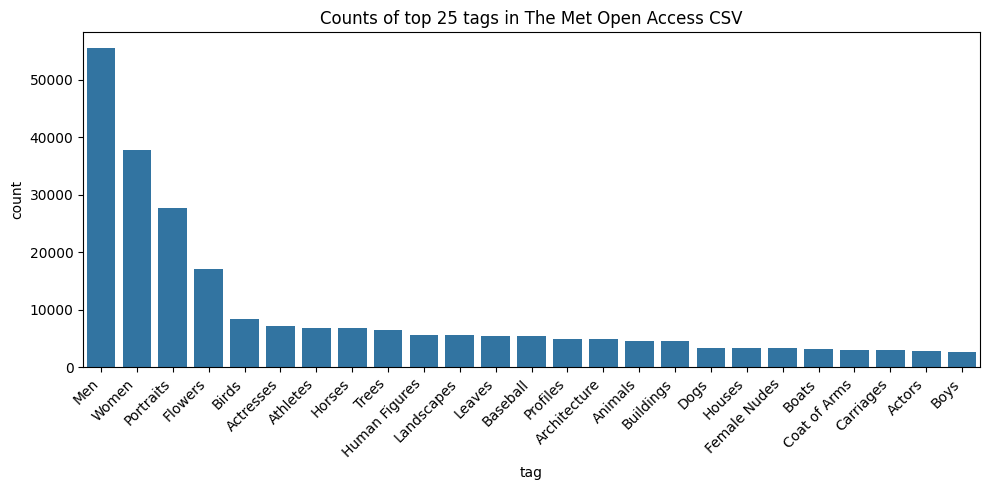

In [187]:
plt.figure(figsize=(10,5))
plt.title("Counts of top 25 tags in The Met Open Access CSV")
sns.barplot(data=top_25_tags, x='tag', y='count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Objects with 'Cats' tag

In [188]:
# How many objects are tagged with 'Cats'
tag_counts.get('Cats')

641

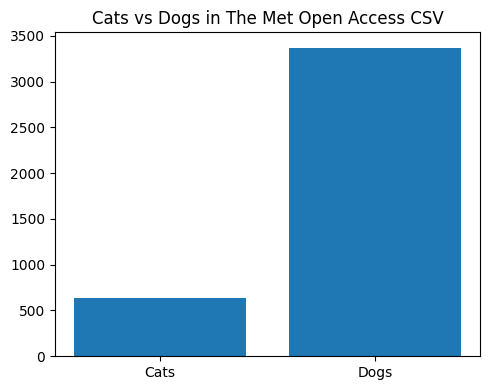

In [189]:
# compare the difference between number of objects tagged with Cats and Dogs
plt.figure(figsize=(5,4))
plt.title("Cats vs Dogs in The Met Open Access CSV")
plt.bar(x=['Cats', 'Dogs'], height=[tag_counts.get('Cats'), tag_counts.get('Dogs')])
plt.tight_layout()
plt.show()

In [190]:
tags_aat_url_map.get('Cats')

'http://vocab.getty.edu/page/aat/300265960'

In [191]:
tags_wiki_url_map.get('Cats')

'https://www.wikidata.org/wiki/Q146'

In [192]:
# find the exact match for objects tagged with 'Cats'
cats_at_the_met = tagged_objects[tagged_objects['Tag_Set'].map(lambda x: 'Cats' in x)]

In [193]:
cats_at_the_met.info()

<class 'pandas.core.frame.DataFrame'>
Index: 641 entries, 243 to 484901
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Object Number            641 non-null    object 
 1   Is Highlight             641 non-null    bool   
 2   Is Timeline Work         641 non-null    bool   
 3   Is Public Domain         641 non-null    bool   
 4   Object ID                641 non-null    int64  
 5   Gallery Number           51 non-null     object 
 6   Department               641 non-null    object 
 7   AccessionYear            637 non-null    object 
 8   Object Name              639 non-null    object 
 9   Title                    598 non-null    object 
 10  Culture                  163 non-null    object 
 11  Period                   115 non-null    object 
 12  Dynasty                  18 non-null     object 
 13  Reign                    7 non-null      object 
 14  Portfolio                4

### Other tags

In [194]:
cats_at_met_tag_counts = Counter(chain.from_iterable(cats_at_the_met['Tag_Set']))
pd.DataFrame(cats_at_met_tag_counts.items(), columns=["tag", "count"]).sort_values(by="count", ascending=False).reset_index(drop=True).head(25)

,tag,count
0,Cats,641
1,Women,232
2,Men,189
3,Dogs,74
4,Satire,70
5,Girls,45
6,Portraits,39
7,Interiors,37
8,Birds,33
9,Boys,27


### Public Domain

What percentage of cat artworks are public domain?

In [195]:
cats_at_the_met['Is Public Domain'].value_counts(normalize=True)

Is Public Domain
True     0.731669
False    0.268331
Name: proportion, dtype: float64

### Department

Let's count the number of cat artworks by department.

In [196]:
cat_department_counts = cats_at_the_met.Department.value_counts().reset_index()
cat_department_counts

,Department,count
0,Drawings and Prints,334
1,Egyptian Art,59
2,Asian Art,57
3,European Sculpture and Decorative Arts,34
4,Photographs,33
5,Modern and Contemporary Art,28
6,"Arts of Africa, Oceania, and the Americas",27
7,The American Wing,24
8,European Paintings,16
9,Costume Institute,9


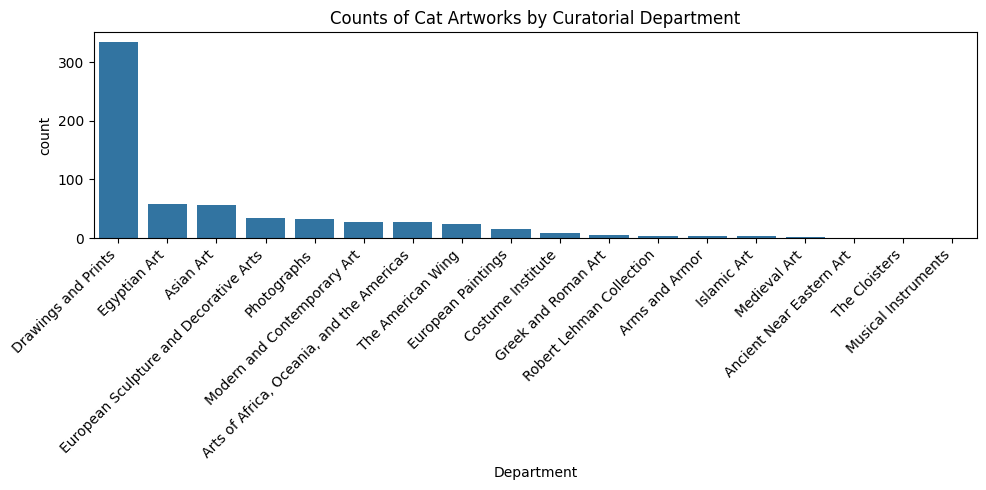

In [209]:
plt.figure(figsize=(10,5))
plt.title("Counts of Cat Artworks by Curatorial Department")
sns.barplot(data=cat_department_counts, x='Department', y='count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Medium

In what mediums is cat artwork?

In [198]:
top_25_cat_medium = cats_at_the_met.Medium.value_counts().reset_index().head(25)
top_25_cat_medium

,Medium,count
0,Hand-colored etching,60
1,Cupreous metal,31
2,Oil on canvas,31
3,Etching,20
4,Lithograph,17
5,Commercial color lithograph,15
6,Etching and engraving,14
7,Engraving,13
8,Wood engraving,13
9,Woodblock print; ink and color on paper,12


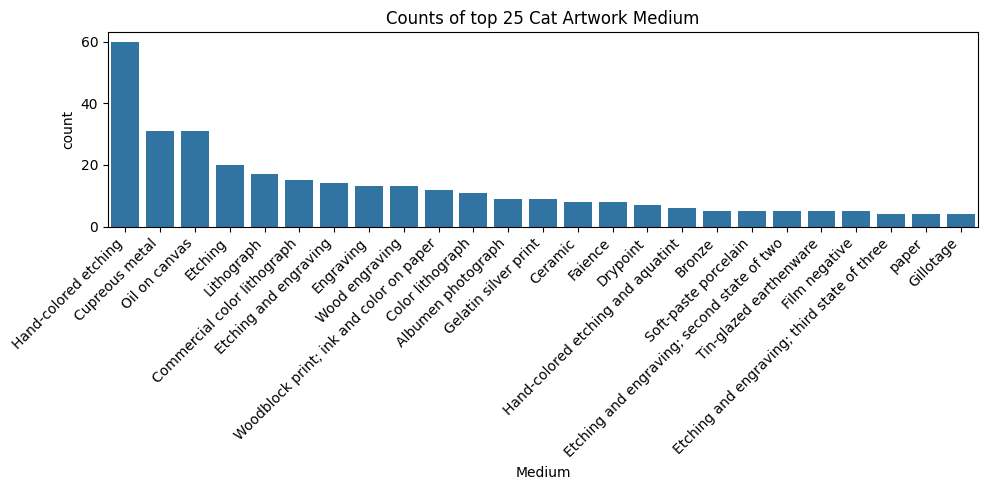

In [199]:
plt.figure(figsize=(10,5))
plt.title("Counts of top 25 Cat Artwork Medium")
sns.barplot(data=top_25_cat_medium, x='Medium', y='count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Classification

In [200]:
cat_art_classification_counts = Counter(chain.from_iterable(cats_at_the_met['Classification_Set']))
top_25_cat_art_classifications = pd.DataFrame(cat_art_classification_counts.items(), columns=['Classification', 'count']).sort_values(by='count', ascending=False).reset_index(drop=True).head(25)
top_25_cat_art_classifications

,Classification,count
0,Prints,305
1,Unknown Classification,92
2,Paintings,47
3,Drawings,41
4,Photographs,34
5,Ephemera,28
6,Posters,14
7,Books,14
8,Ceramics-Containers,13
9,Ceramics-Pottery,11


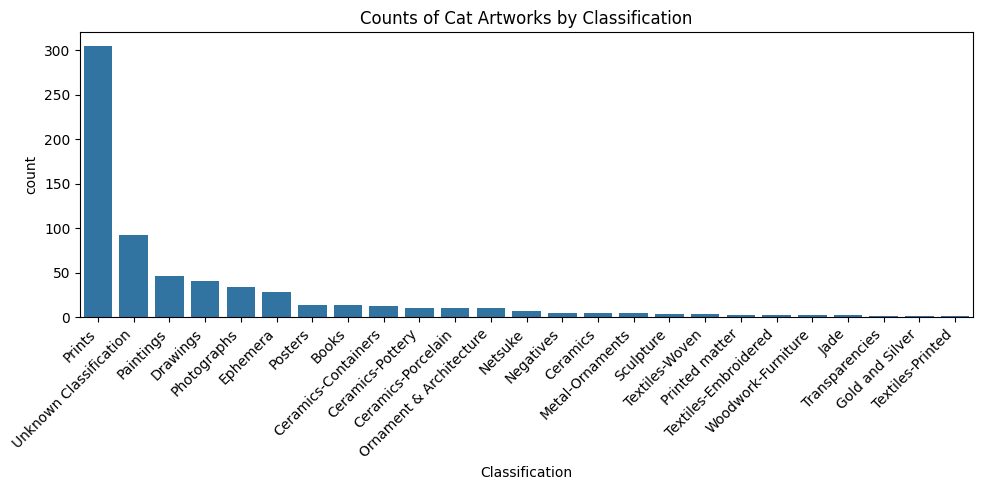

In [210]:
plt.figure(figsize=(10,5))
plt.title("Counts of Cat Artworks by Classification")
sns.barplot(data=top_25_cat_art_classifications, x='Classification', y='count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Artists

#### Artist Name

Let's look at Artists who created cat artworks.

In [202]:
cat_artist_names_counts = Counter(chain.from_iterable(cats_at_the_met['Artist_Name_Set']))
top_25_cat_artists = pd.DataFrame(cat_artist_names_counts.items(), columns=['Artist Name', 'count']).sort_values(by='count', ascending=False).reset_index(drop=True).head(25)
top_25_cat_artists

,Artist Name,count
0,No Artist Name,146
1,Thomas Rowlandson,78
2,William Hogarth,19
3,"Rudolph Ackermann, London",17
4,Thomas Tegg,16
5,François Boucher,14
6,Edward Penfield,12
7,Edouard Manet,10
8,S. W. Fores,10
9,Théophile-Alexandre Steinlen,10


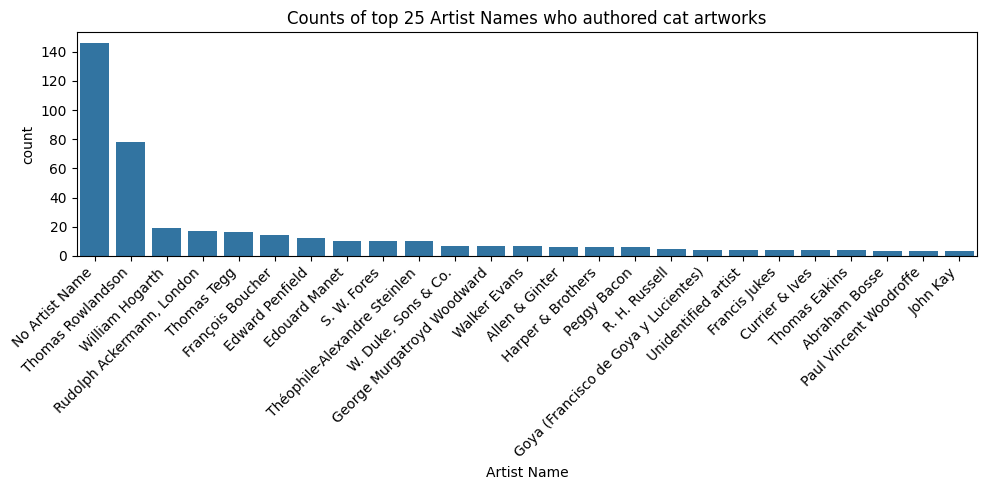

In [203]:
plt.figure(figsize=(10,5))
plt.title("Counts of top 25 Artist Names who authored cat artworks")
sns.barplot(data=top_25_cat_artists, x='Artist Name', y='count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Artist Nationality

In [204]:
cat_artist_nationilty_counts = Counter(chain.from_iterable(cats_at_the_met['Artist_Nationality_Set']))
top_25_cat_artist_nationalities = pd.DataFrame(cat_artist_nationilty_counts.items(), columns=['Artist Nationality', 'count']).sort_values(by='count', ascending=False).reset_index(drop=True).head(25)
top_25_cat_artist_nationalities

,Artist Nationality,count
0,Unknown Nationality,146
1,British,141
2,American,121
3,French,92
4,,50
5,Japanese,28
6,Italian,18
7,German,17
8,Dutch,10
9,Spanish,10


## Additional Queries

In [220]:
for i, row in tagged_objects[tagged_objects['Tag_Set'].map(lambda x: {'Cats', 'Monkeys'}.issubset(x))].iterrows():
    print(row['Link Resource'])

http://www.metmuseum.org/art/collection/search/12855
http://www.metmuseum.org/art/collection/search/222231
http://www.metmuseum.org/art/collection/search/355617
http://www.metmuseum.org/art/collection/search/365591
http://www.metmuseum.org/art/collection/search/384765
http://www.metmuseum.org/art/collection/search/403228
http://www.metmuseum.org/art/collection/search/403248
http://www.metmuseum.org/art/collection/search/463188
http://www.metmuseum.org/art/collection/search/662262
http://www.metmuseum.org/art/collection/search/788941


In [ ]:
# find objects that have both 'Cats' and 'Dogs' tags
cats_and_dogs_at_the_met = tagged_objects[tagged_objects['Tag_Set'].map(lambda x: {'Cats', 'Dogs'}.issubset(x))]

In [212]:
cats_and_dogs_at_the_met.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 105085 to 327977
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Object Number            10 non-null     object 
 1   Is Highlight             10 non-null     bool   
 2   Is Timeline Work         10 non-null     bool   
 3   Is Public Domain         10 non-null     bool   
 4   Object ID                10 non-null     int64  
 5   Gallery Number           1 non-null      object 
 6   Department               10 non-null     object 
 7   AccessionYear            10 non-null     object 
 8   Object Name              10 non-null     object 
 9   Title                    10 non-null     object 
 10  Culture                  1 non-null      object 
 11  Period                   0 non-null      object 
 12  Dynasty                  0 non-null      object 
 13  Reign                    0 non-null      object 
 14  Portfolio               

In [207]:
# find objects that have either 'Cats' or 'Monkeys' tags
cats_or_monkeys_at_the_met = tagged_objects[tagged_objects['Tag_Set'].map(lambda x: bool(x & {'Cats', 'Monkeys'}))]

In [208]:
cats_or_monkeys_at_the_met.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1104 entries, 243 to 484901
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Object Number            1104 non-null   object 
 1   Is Highlight             1104 non-null   bool   
 2   Is Timeline Work         1104 non-null   bool   
 3   Is Public Domain         1104 non-null   bool   
 4   Object ID                1104 non-null   int64  
 5   Gallery Number           104 non-null    object 
 6   Department               1104 non-null   object 
 7   AccessionYear            1099 non-null   object 
 8   Object Name              1101 non-null   object 
 9   Title                    949 non-null    object 
 10  Culture                  465 non-null    object 
 11  Period                   253 non-null    object 
 12  Dynasty                  45 non-null     object 
 13  Reign                    15 non-null     object 
 14  Portfolio                